In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../Anita_Project_Datasets/pkm/PKMN_DB.csv')
df.head()

,Pokedex_Number,Pokemon_Name,Generation,Type_1,Type_2,Ability_1,Ability_2,Hidden_Ability,HP,Attack,Defense,Special_Attack,Special_Defense,Speed,BST,Sub_Class,Stage
0,1,Bulbasaur,1,Grass,Poison,Overgrow,NaN,Chlorophyll,45,49,49,65,65,45,318,Starter,1
1,2,Ivysaur,1,Grass,Poison,Overgrow,NaN,Chlorophyll,60,62,63,80,80,60,405,Starter,2
2,3,Venusaur,1,Grass,Poison,Overgrow,NaN,Chlorophyll,80,82,83,100,100,80,525,Starter,3
3,4,Mega_Venusaur,6,Grass,Poison,Thick_Fat,NaN,NaN,80,100,123,122,120,80,625,Starter_Mega_Evolution,3
4,5,Charmander,1,Fire,NaN,Blaze,NaN,Solar_Power,39,52,43,60,50,65,309,Starter,1


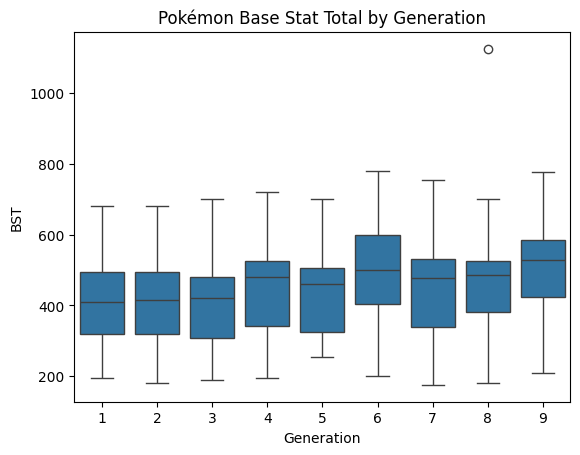

In [5]:
sns.boxplot(data=df, x="Generation", y="BST")
plt.title("Pokémon Base Stat Total by Generation")
plt.show()

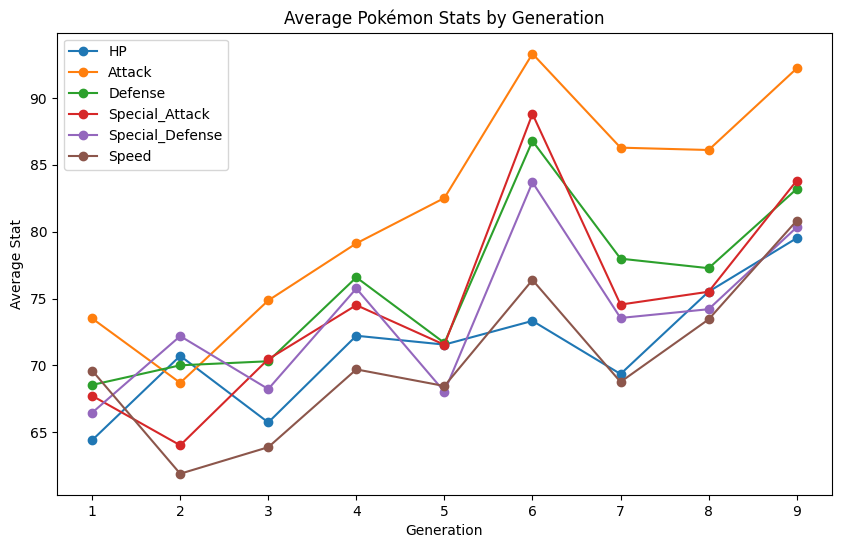

In [6]:
stats = ["HP", "Attack", "Defense", "Special_Attack", "Special_Defense", "Speed"]

generation_stats = df.groupby("Generation")[stats].mean()

generation_stats.plot(kind="line", marker="o", figsize=(10,6))
plt.ylabel("Average Stat")
plt.title("Average Pokémon Stats by Generation")
plt.show()

In [7]:
type_stats = df.groupby("Type_1")["BST"].agg(["mean", "median", "std", "count"])
type_stats.sort_values("mean", ascending=False)

,mean,median,std,count
Type_1,,,,
Dragon,542.053571,590.0,141.207188,56
Steel,494.622222,500.0,119.535329,45
Psychic,488.166667,490.0,141.384022,84
Fighting,470.218182,490.0,111.926016,55
Fire,466.250000,490.0,111.527087,80
Fairy,462.088235,481.5,134.027670,34
Dark,460.316667,485.0,117.912851,60
Electric,458.217949,490.0,112.959555,78
Rock,453.871429,487.0,108.761396,70


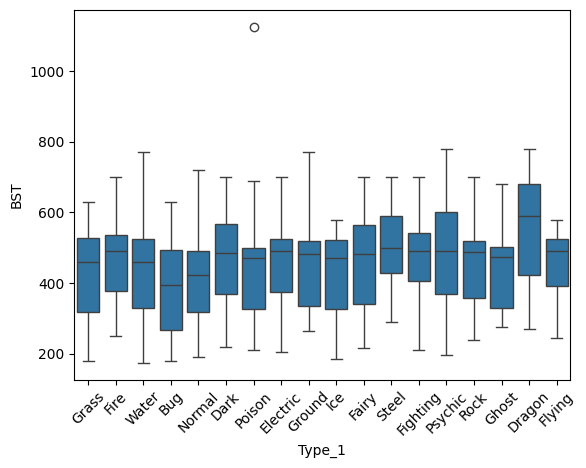

In [8]:
sns.boxplot(data=df, x="Type_1", y="BST")
plt.xticks(rotation=45)
plt.show()

In [9]:
df["Dual_Type"] = df["Type_2"].notna()

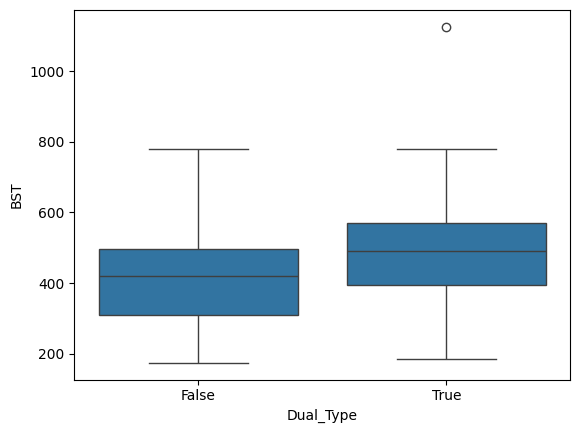

In [10]:
sns.boxplot(data=df, x="Dual_Type", y="BST")
plt.show()

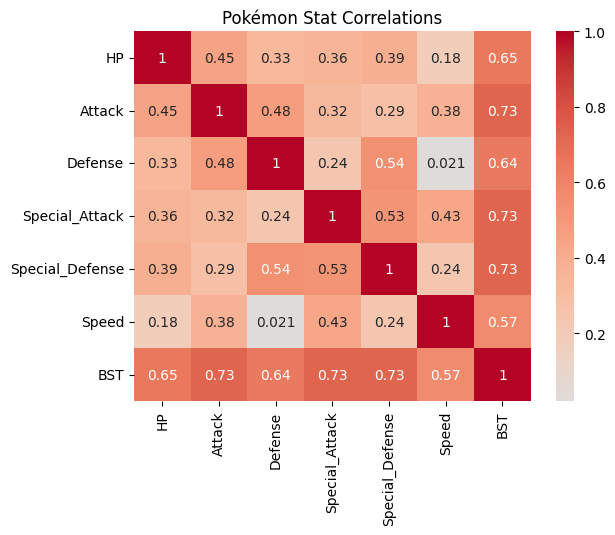

In [11]:
stats = ["HP", "Attack", "Defense", "Special_Attack",
         "Special_Defense", "Speed", "BST"]

corr = df[stats].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Pokémon Stat Correlations")
plt.show()

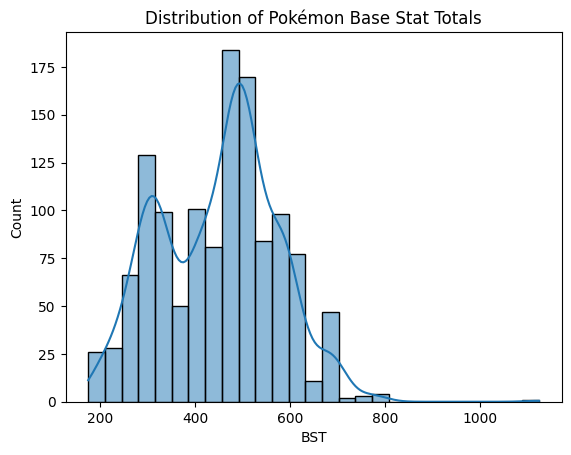

In [12]:
sns.histplot(df["BST"], kde=True)
plt.title("Distribution of Pokémon Base Stat Totals")
plt.show()

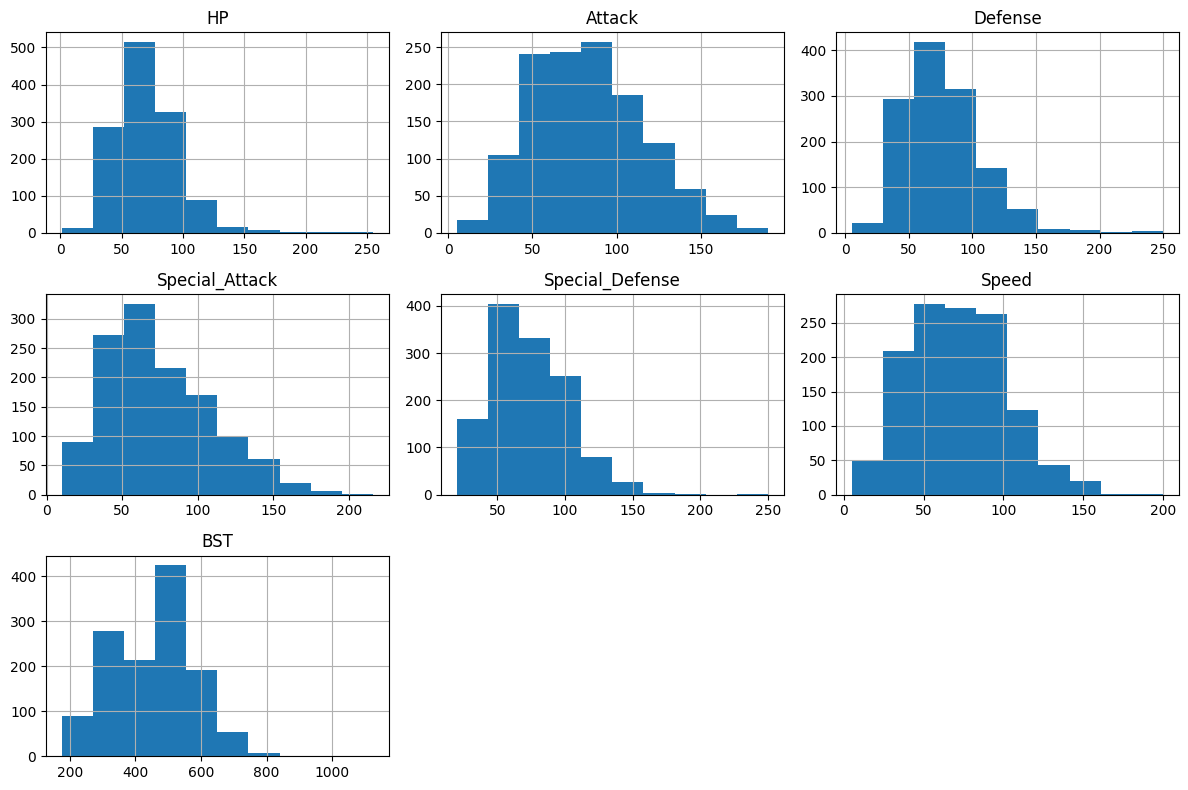

In [13]:
df[stats].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

In [14]:
df["Strong"] = df["BST"] >= df["BST"].quantile(0.75)

In [15]:
pd.crosstab(df["Type_1"], df["Strong"], normalize="index")

Strong,False,True
Type_1,,
Bug,0.881720,0.118280
Dark,0.700000,0.300000
Dragon,0.428571,0.571429
Electric,0.756410,0.243590
Fairy,0.647059,0.352941
Fighting,0.727273,0.272727
Fire,0.637500,0.362500
Flying,0.700000,0.300000
Ghost,0.854167,0.145833


In [16]:
pd.crosstab(df["Generation"], df["Strong"], normalize="index")

Strong,False,True
Generation,,
1,0.901961,0.098039
2,0.873786,0.126214
3,0.829787,0.170213
4,0.779661,0.220339
5,0.842424,0.157576
6,0.553846,0.446154
7,0.716667,0.283333
8,0.761905,0.238095
9,0.500000,0.500000


In [17]:
pd.crosstab(df["Dual_Type"], df["Strong"], normalize="index")

Strong,False,True
Dual_Type,,
False,0.846570,0.153430
True,0.663366,0.336634


In [18]:
for col in ["Ability_1", "Ability_2", "Hidden_Ability"]:
    print(df[col].value_counts().head(10))

Ability_1
Levitate       43
Intimidate     35
Swift_Swim     32
Keen_Eye       29
Overgrow       28
Blaze          28
Torrent        28
Chlorophyll    28
Pressure       28
Swarm          23
Name: count, dtype: int64
Ability_2
Frisk          20
Sturdy         18
Shell_Armor    16
Own_Tempo      15
Gluttony       14
Inner_Focus    11
Hustle         10
Technician     10
Infiltrator    10
Flash_Fire      9
Name: count, dtype: int64
Hidden_Ability
Sheer_Force    22
Telepathy      22
Regenerator    20
Overcoat       19
Unnerve        18
Weak_Armor     17
Infiltrator    16
Rattled        16
Sand_Veil      14
Pickpocket     14
Name: count, dtype: int64


In [19]:
abilities = pd.concat([
    df["Ability_1"],
    df["Ability_2"],
    df["Hidden_Ability"]
])

abilities.value_counts().head(20)

Intimidate     47
Swift_Swim     47
Sturdy         47
Keen_Eye       43
Levitate       43
Inner_Focus    38
Chlorophyll    38
Frisk          36
Gluttony       35
Sheer_Force    35
Run_Away       34
Pressure       34
Own_Tempo      33
Thick_Fat      31
Swarm          31
Overgrow       30
Blaze          30
Torrent        30
Sand_Veil      29
Pickup         29
Name: count, dtype: int64

In [20]:
df.groupby("Ability_1")["BST"].mean().sort_values(ascending=False).head(20)

Ability_1
Delta_Stream        780.0
Desolate_Land       770.0
Primordial_Sea      770.0
Neuroforce          754.0
Multitype           720.0
Power_Construct     708.0
Teraform_Zero       700.0
Multiscale          700.0
Turboblaze          690.0
Teravolt            690.0
Shadow_Shield       680.0
Full_Metal_Body     680.0
Intrepid_Sword      680.0
Dauntless_Shield    680.0
Dark_Aura           680.0
As_One              680.0
Air_Lock            680.0
Drizzle             670.0
Hadron_Engine       670.0
Orichalcum_Pulse    670.0
Name: BST, dtype: float64

In [21]:
df.groupby("Stage")["BST"].agg(["mean", "median", "std", "count"])

,mean,median,std,count
Stage,,,,
1,414.338392,355.0,145.653164,659
2,466.059633,480.0,71.070573,436
3,545.138554,530.0,64.247241,166


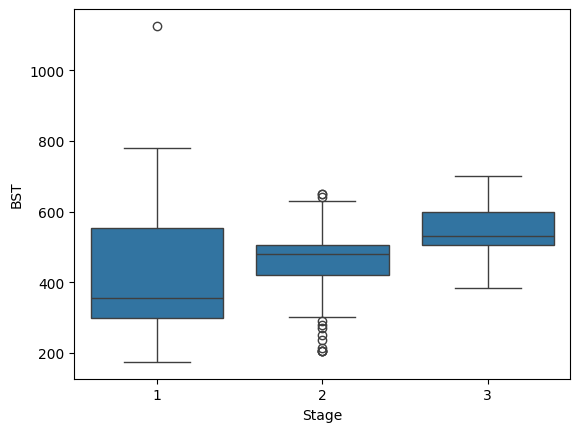

In [23]:
sns.boxplot(data=df, x="Stage", y="BST")
plt.show()

In [24]:
df.groupby("Stage")[stats].mean()

,HP,Attack,Defense,Special_Attack,Special_Defense,Speed,BST
Stage,,,,,,,
1,65.776935,75.088012,69.828528,68.349014,67.359636,67.936267,414.338392
2,75.516055,85.848624,80.162844,76.623853,76.837156,71.071101,466.059633
3,84.656627,102.572289,89.246988,96.710843,89.722892,82.228916,545.138554


In [25]:
df["Is_Starter"] = df["Sub_Class"].str.contains("Starter", na=False)

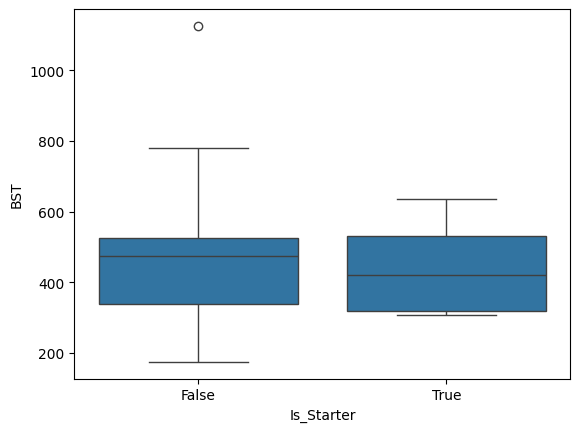

In [26]:
sns.boxplot(data=df, x="Is_Starter", y="BST")
plt.show()

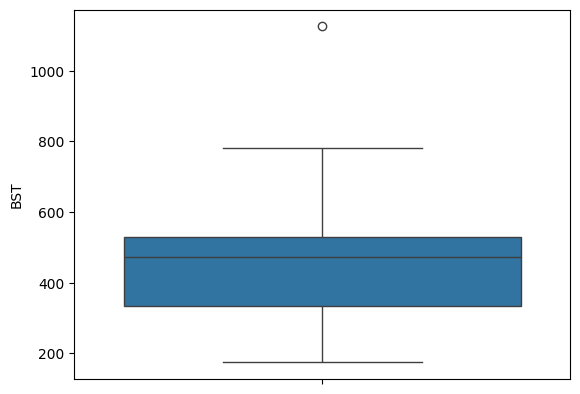

In [27]:
sns.boxplot(data=df, y="BST")
plt.show()

In [28]:
Q1 = df["BST"].quantile(.25)
Q3 = df["BST"].quantile(.75)

IQR = Q3 - Q1

outliers = df[
    (df["BST"] < Q1 - 1.5*IQR) |
    (df["BST"] > Q3 + 1.5*IQR)
]

outliers[["Pokemon_Name", "BST"]]

,Pokemon_Name,BST
1117,Eternamax,1125


In [29]:
stats = ["HP", "Attack", "Defense", "Special_Attack",
         "Special_Defense", "Speed"]

df["Stat_Max"] = df[stats].max(axis=1)
df["Stat_Min"] = df[stats].min(axis=1)
df["Stat_Range"] = df["Stat_Max"] - df["Stat_Min"]

In [30]:
df.sort_values("Stat_Range", ascending=False)[
    ["Pokemon_Name"] + stats + ["Stat_Range"]
].head(20)

,Pokemon_Name,HP,Attack,Defense,Special_Attack,Special_Defense,Speed,Stat_Range
174,Chansey,250,5,5,35,105,50,245
175,Blissey,255,10,10,75,135,55,245
320,Shuckle,20,10,230,10,230,5,225
146,Mega_Steelix,75,125,230,55,95,30,200
1026,Stakataka,61,131,211,53,101,13,198
1016,Guzzlord,223,101,53,97,53,43,180
431,Mega_Aggron,70,140,230,60,80,50,180
145,Steelix,75,85,200,55,65,30,170
537,Deoxys_Attack_Forme,50,180,20,180,20,150,160
305,Wobbuffet,190,33,58,33,58,33,157


In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

stats = ["HP", "Attack", "Defense",
         "Special_Attack", "Special_Defense", "Speed"]

X = StandardScaler().fit_transform(df[stats])

pca = PCA()
X_pca = pca.fit_transform(X)

print(pca.explained_variance_ratio_)

[0.45842904 0.18138575 0.13661849 0.11049295 0.06827737 0.0447964 ]


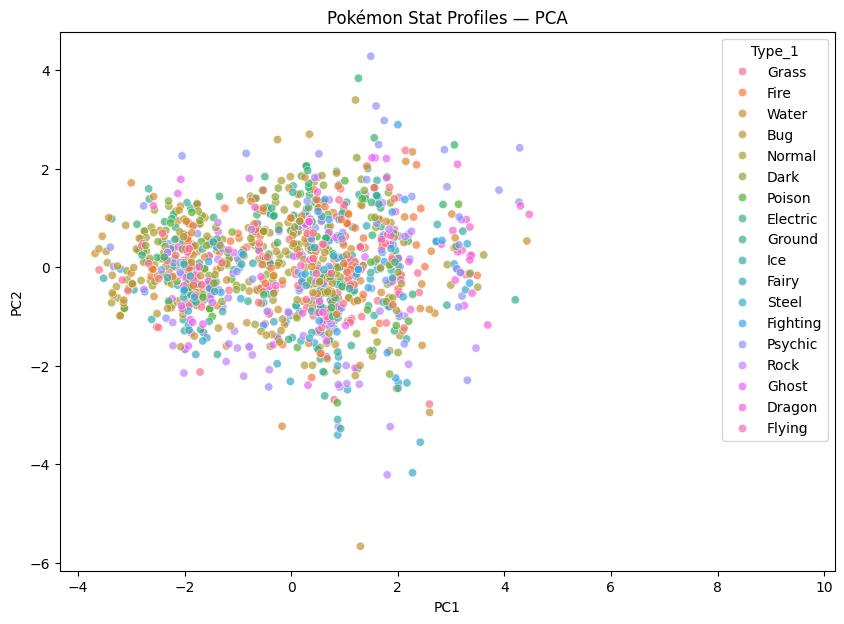

In [32]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["Type_1"],
    alpha=.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Pokémon Stat Profiles — PCA")
plt.show()

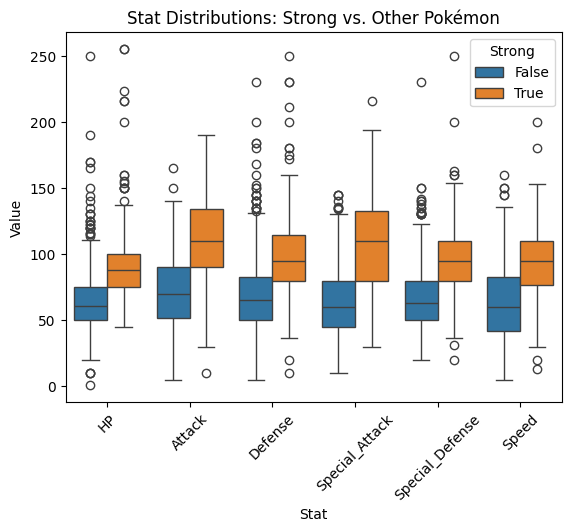

In [33]:
stats = ["HP", "Attack", "Defense", "Special_Attack",
         "Special_Defense", "Speed"]

strong_long = df.melt(
    id_vars="Strong",
    value_vars=stats,
    var_name="Stat",
    value_name="Value"
)

sns.boxplot(data=strong_long, x="Stat", y="Value", hue="Strong")
plt.title("Stat Distributions: Strong vs. Other Pokémon")
plt.xticks(rotation=45)
plt.show()

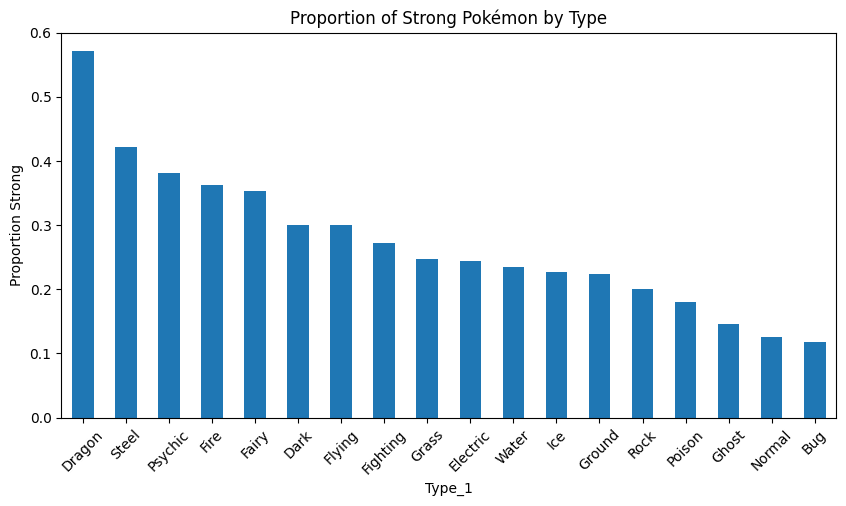

In [34]:
strong_by_type = (
    df.groupby("Type_1")["Strong"]
      .mean()
      .sort_values(ascending=False)
)

strong_by_type.plot(kind="bar", figsize=(10,5))
plt.ylabel("Proportion Strong")
plt.title("Proportion of Strong Pokémon by Type")
plt.xticks(rotation=45)
plt.show()

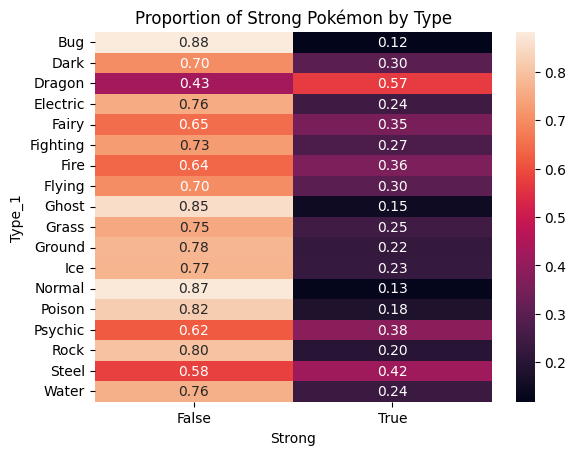

In [35]:
type_strength = pd.crosstab(
    df["Type_1"],
    df["Strong"],
    normalize="index"
)

sns.heatmap(type_strength, annot=True, fmt=".2f")
plt.title("Proportion of Strong Pokémon by Type")
plt.show()

In [36]:
dual = df.dropna(subset=["Type_2"])

dual["Type_Combination"] = (
    dual["Type_1"] + " / " + dual["Type_2"]
)

dual.groupby("Type_Combination")["Strong"].mean().sort_values(
    ascending=False
).head(20)

Type_Combination
Fire / Dark            1.0
Fighting / Ghost       1.0
Fighting / Electric    1.0
Fighting / Dragon      1.0
Electric / Ground      1.0
Dragon / Fairy         1.0
Dragon / Fire          1.0
Dragon / Psychic       1.0
Dragon / Electric      1.0
Dark / Grass           1.0
Dragon / Dark          1.0
Dark / Ground          1.0
Fairy / Fighting       1.0
Fairy / Psychic        1.0
Poison / Ghost         1.0
Rock / Dark            1.0
Psychic / Steel        1.0
Psychic / Ice          1.0
Ground / Normal        1.0
Ice / Fire             1.0
Name: Strong, dtype: float64

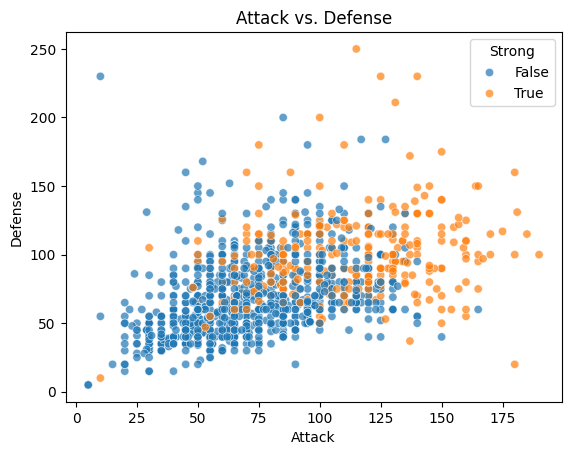

In [37]:
sns.scatterplot(
    data=df,
    x="Attack",
    y="Defense",
    hue="Strong",
    alpha=.7
)

plt.title("Attack vs. Defense")
plt.show()

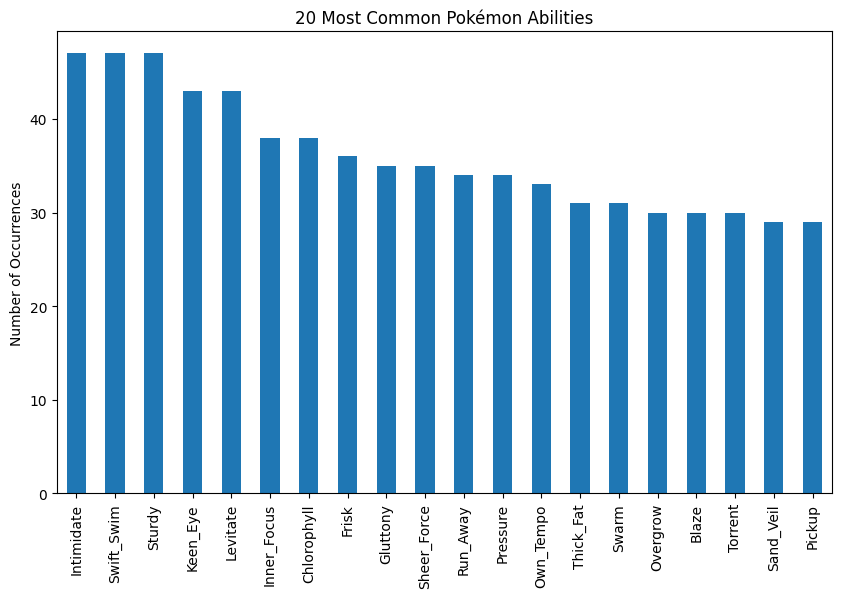

In [38]:
abilities = pd.concat([
    df["Ability_1"],
    df["Ability_2"],
    df["Hidden_Ability"]
])

abilities.value_counts().head(20).plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("20 Most Common Pokémon Abilities")
plt.ylabel("Number of Occurrences")
plt.show()

In [39]:
ability_bst = (
    df.groupby("Ability_1")["BST"]
      .agg(["mean", "count"])
      .query("count >= 5")
      .sort_values("mean", ascending=False)
)

ability_bst.head(20)

,mean,count
Ability_1,,
Tough_Claws,607.200000,5
Pressure,592.464286,28
Justified,580.000000,5
Quark_Drive,578.000000,10
Protosynthesis,578.000000,10
Beast_Boost,553.636364,11
Serene_Grace,550.714286,7
Defiant,513.333333,6
No_Guard,507.400000,5


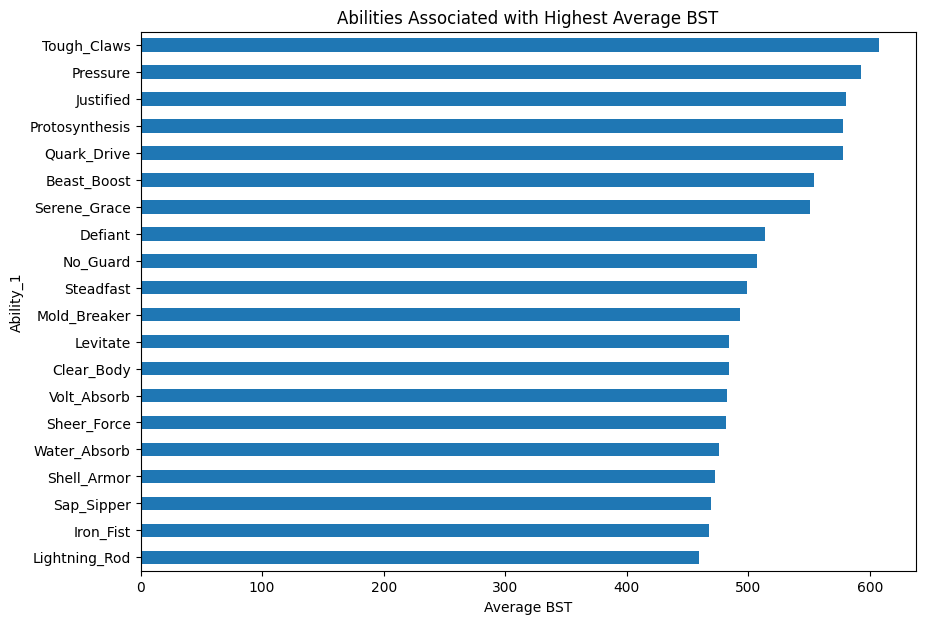

In [40]:
ability_bst.head(20)["mean"].sort_values().plot(
    kind="barh",
    figsize=(10,7)
)

plt.xlabel("Average BST")
plt.title("Abilities Associated with Highest Average BST")
plt.show()

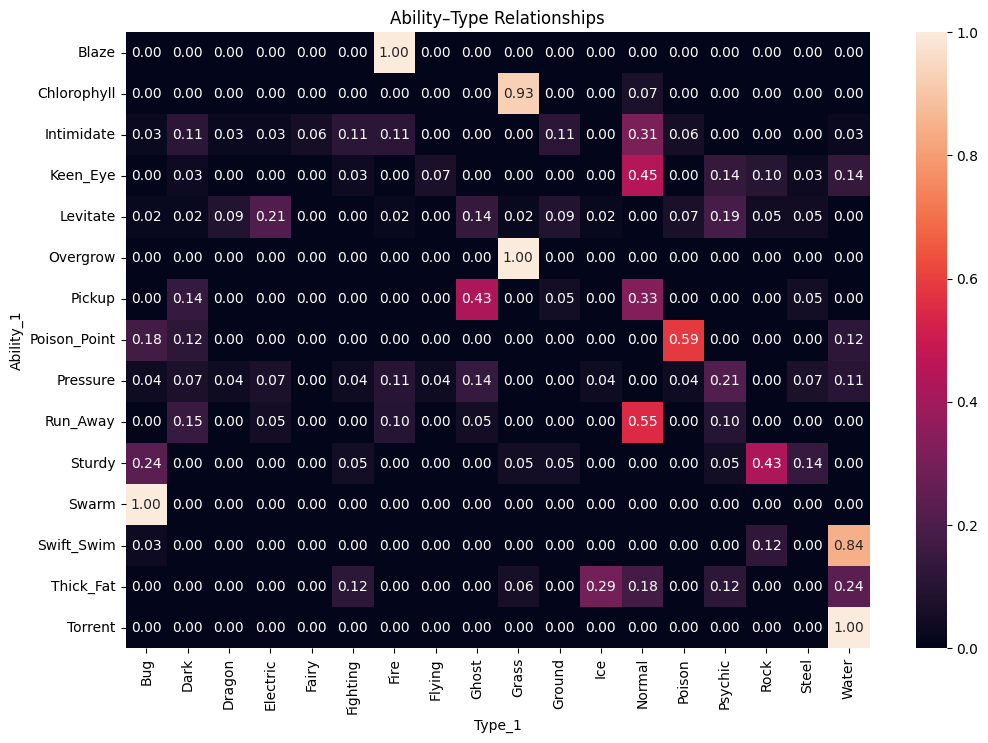

In [41]:
top_abilities = df["Ability_1"].value_counts().head(15).index

ability_type = pd.crosstab(
    df[df["Ability_1"].isin(top_abilities)]["Ability_1"],
    df[df["Ability_1"].isin(top_abilities)]["Type_1"],
    normalize="index"
)

plt.figure(figsize=(12,8))
sns.heatmap(ability_type, annot=True, fmt=".2f")
plt.title("Ability–Type Relationships")
plt.show()

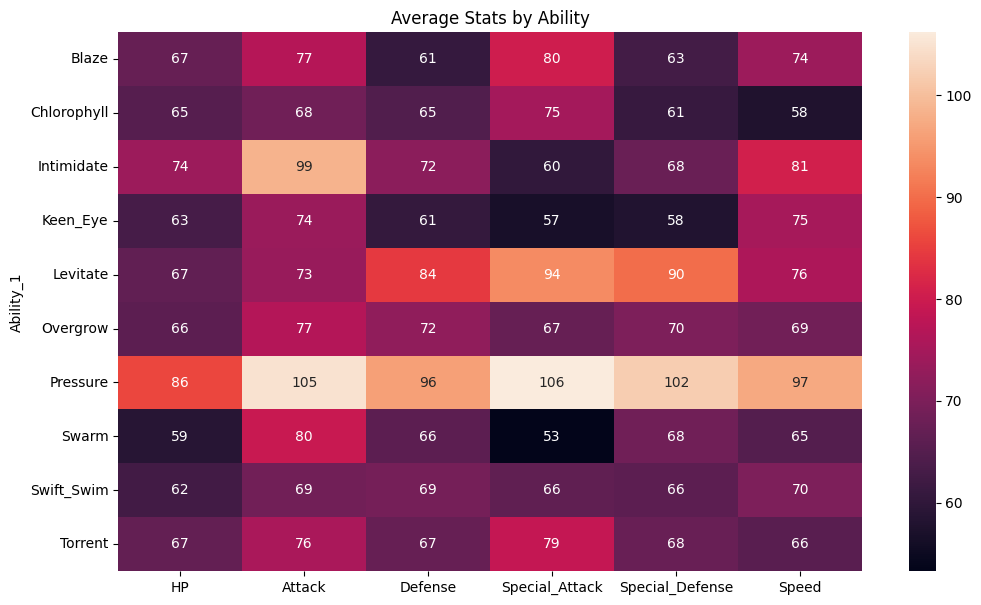

In [42]:
top_abilities = df["Ability_1"].value_counts().head(10).index

ability_stats = (
    df[df["Ability_1"].isin(top_abilities)]
    .groupby("Ability_1")[stats]
    .mean()
)

plt.figure(figsize=(12,7))
sns.heatmap(ability_stats, annot=True, fmt=".0f")
plt.title("Average Stats by Ability")
plt.show()

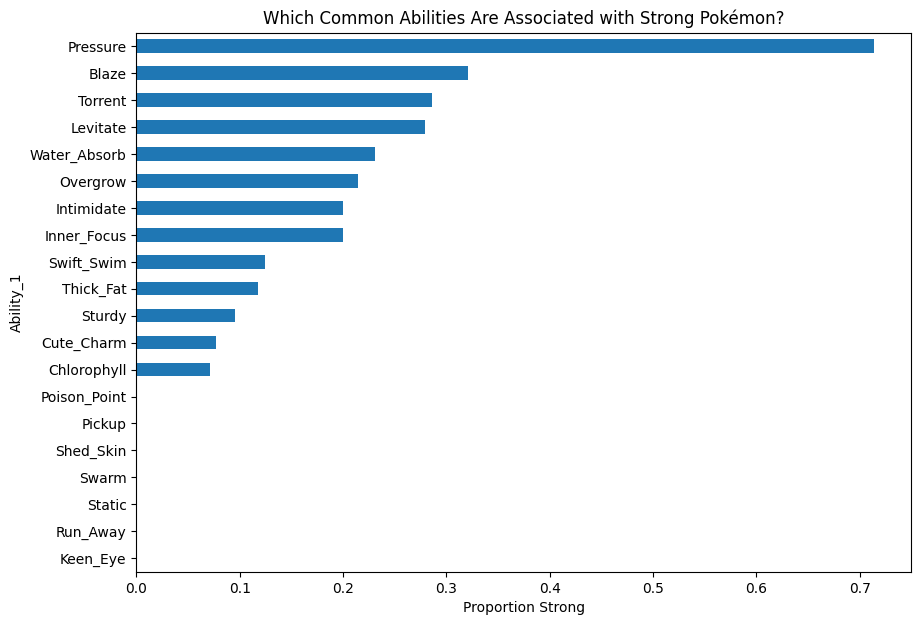

In [43]:
top_abilities = df["Ability_1"].value_counts().head(20).index

plot_data = (
    df[df["Ability_1"].isin(top_abilities)]
    .groupby("Ability_1")["Strong"]
    .mean()
    .sort_values()
)

plot_data.plot(kind="barh", figsize=(10,7))

plt.xlabel("Proportion Strong")
plt.title("Which Common Abilities Are Associated with Strong Pokémon?")
plt.show()

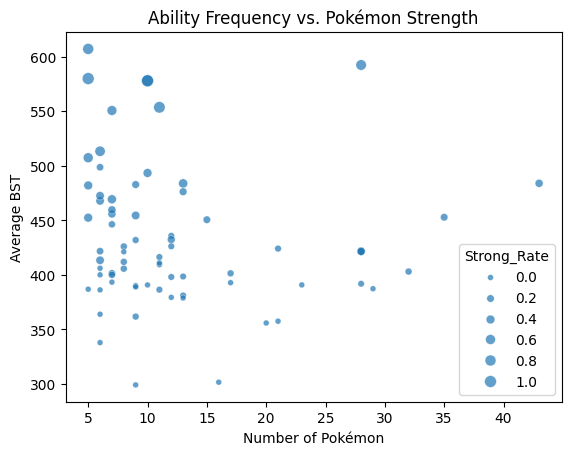

In [44]:
ability_summary = (
    df.groupby("Ability_1")
      .agg(
          Avg_BST=("BST", "mean"),
          Count=("BST", "size"),
          Strong_Rate=("Strong", "mean")
      )
)

ability_summary = ability_summary[ability_summary["Count"] >= 5]

sns.scatterplot(
    data=ability_summary,
    x="Count",
    y="Avg_BST",
    size="Strong_Rate",
    alpha=.7
)

plt.xlabel("Number of Pokémon")
plt.ylabel("Average BST")
plt.title("Ability Frequency vs. Pokémon Strength")
plt.show()